¡Hola, Jhovanna!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-analyst. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>


# Proyecto de pruebas A/B

El objetivo de este estudio es evaluar si la prueba A/B recommender_system_test fue implementada correctamente y determinar si el nuevo sistema de recomendaciones mejora el comportamiento de los usuarios con respecto al embudo de conversión.

En particular, se analizará si existe un incremento mínimo del 10% en las conversiones entre las etapas:

product_page
product_cart
purchase

Además, se verificará la calidad de los datos, el cumplimiento del diseño experimental y finalmente se aplicarán pruebas estadísticas para determinar si las diferencias entre los grupos A y B son significativas.

In [57]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [58]:
# Cargar archivo de datos
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

In [59]:
marketing.info()
marketing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [60]:
users.info()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [61]:
events.info()
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [62]:
participants.info()
participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [63]:
# Convertir columnas de fecha a Datetime.
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

In [64]:
users['first_date'] = pd.to_datetime(users['first_date'])

In [65]:
events['event_dt'] = pd.to_datetime(events['event_dt'])

In [66]:
# Revisar valores ausentes
marketing.isna().sum()

name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

In [67]:
users.isna().sum()

user_id       0
first_date    0
region        0
device        0
dtype: int64

In [68]:
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

El dataset presenta valores ausentes únicamente en la columna details del archivo de eventos. Esto es esperado, ya que únicamente los eventos purchase contienen información adicional sobre el monto de la compra. En consecuencia, estos valores faltantes no representan un problema para el análisis.

In [69]:
participants.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [70]:
# Revisar duplicados
marketing.duplicated().sum()

0

In [71]:
users.duplicated().sum()

0

In [72]:
events.duplicated().sum()

0

In [73]:
participants.duplicated().sum()

0

<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Gran trabajo con la carga inicial de los datos, esto lo complementas mediante las funciones head. 

Realizas de manera perfecta el análisis de valores nulos y duplicados que pudieran sesgar nuestros resultados. 

In [74]:
# Unir los datos
df = (participants.merge(users, on='user_id').merge(events, on='user_id', how='left'))

In [75]:
df.head()

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,purchase,99.99
1,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:29,product_cart,NaN
2,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,product_page,NaN
3,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,login,NaN
4,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone,2020-12-20 15:46:06,product_page,NaN


In [76]:
# Filtrar únicamente usuarios de la Unión Europea
df = df[df['region'] == 'EU']

In [77]:
# Verificar
df['region'].value_counts()

EU    101603
Name: region, dtype: int64

In [78]:
# Filtrar unicamente la prueba
df = df[df['ab_test'] == 'recommender_system_test']

In [79]:
# Verificar
df['ab_test'].value_counts()

recommender_system_test    22674
Name: ab_test, dtype: int64

In [80]:
#Verificar que solo se consideran los primeros 14 días desde el registro
df['days_after_registration'] = (
    df['event_dt'] - df['first_date']
).dt.days

In [81]:
# Vereficar
df['days_after_registration'].describe()

count    22674.000000
mean         3.150613
std          4.050777
min          0.000000
25%          0.000000
50%          2.000000
75%          5.000000
max         23.000000
Name: days_after_registration, dtype: float64

In [82]:
df['days_after_registration'].max()

23

In [83]:
# Filtrar
df = df[
    (df['days_after_registration'] >= 0) &
    (df['days_after_registration'] <= 14)
]

Se verificó que únicamente se consideraran los eventos ocurridos durante los primeros 14 días posteriores al registro de cada usuario, tal como lo especifica el diseño de la prueba A/B. Los eventos posteriores a este periodo fueron excluidos del análisis para garantizar que los resultados correspondieran al intervalo de evaluación definido.

In [84]:
# Verificar que las pruebas sean excluyentes
multiple_tests = (
    participants
    .groupby('user_id')['ab_test']
    .nunique()
)

multiple_tests = multiple_tests[multiple_tests > 1]

len(multiple_tests)

887

In [85]:
# Eliminar esos usuarios
df = df[~df['user_id'].isin(multiple_tests.index)]

In [86]:
# Verificar
df['user_id'].nunique()

2594

## Parte 1. Analisis exploratorio (EDA)

In [87]:
# Participantes por grupo
participants_group = (df.groupby('group')['user_id'].nunique())
participants_group.head()

group
A    1939
B     655
Name: user_id, dtype: int64

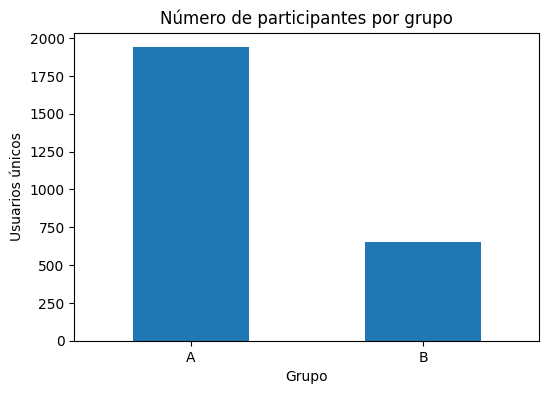

In [88]:
# Grafico del número de participantes por grupo
participants_group.plot(
    kind='bar',
    figsize=(6,4),
    rot=0
)

plt.title('Número de participantes por grupo')
plt.xlabel('Grupo')
plt.ylabel('Usuarios únicos')

plt.show()

se observa que el grupo A está conformado por 1,939 usuarios, mientras que el grupo B cuenta con 655 usuarios. Esto evidencia que la distribución de participantes entre ambos grupos no es equilibrada, ya que el grupo de control tiene aproximadamente tres veces más usuarios que el grupo experimental. Este desequilibrio debe considerarse al interpretar los resultados de la prueba A/B, pues puede influir en la precisión de las comparaciones estadísticas y en la capacidad para detectar diferencias entre los grupos.

In [89]:
# Eventos por usuario
events_per_user = (df.groupby('user_id').size())

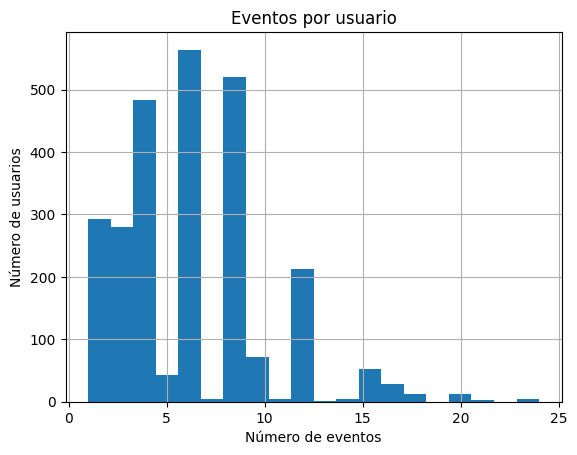

In [90]:
# Histograma de eventos por usuario
events_per_user.hist(bins=20)
plt.title("Eventos por usuario")
plt.xlabel("Número de eventos")
plt.ylabel("Número de usuarios")
plt.show()

El histograma muestra la distribución del número de eventos realizados por usuario durante la prueba A/B. Se observa que la mayoría de los usuarios realizó un número reducido de eventos, mientras que un grupo mucho menor registró una mayor cantidad de interacciones. Esta distribución presenta una concentración en valores bajos y una disminución gradual conforme aumenta el número de eventos por usuario, lo que indica que la actividad no se distribuye de manera uniforme entre todos los participantes.

In [91]:
# Eventos por usuario y grupo
events_per_user_group = (df.groupby(['group','user_id']).size().reset_index(name='events'))

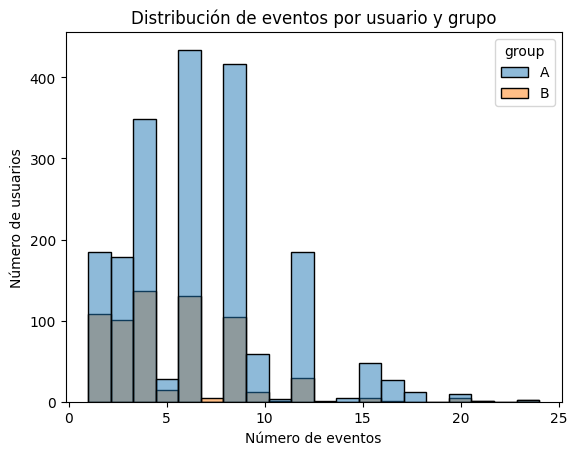

In [92]:
# Histogrma de eventos por usuario y grupo
sns.histplot(data=events_per_user_group, x='events', hue='group', bins=20)

plt.title('Distribución de eventos por usuario y grupo')
plt.xlabel('Número de eventos')
plt.ylabel('Número de usuarios')
plt.show()

La distribución del número de eventos por usuario muestra que, tanto en el grupo A como en el grupo B, la mayoría de los participantes realizó un número reducido de interacciones durante el período de la prueba. A medida que aumenta el número de eventos por usuario, la cantidad de participantes disminuye considerablemente, lo que indica un patrón de comportamiento similar entre ambos grupos. Asimismo, el grupo A presenta una mayor frecuencia de usuarios debido a que cuenta con un número superior de participantes (1,939 frente a 655 en el grupo B). En general, no se observan diferencias importantes en la forma de la distribución de eventos por usuario, por lo que el comportamiento individual de los participantes resulta comparable entre los grupos. La principal diferencia corresponde al tamaño de las muestras y no al patrón de actividad de los usuarios.

<div class="alert alert-block alert-danger">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Excelente trabajo,  antes de realizar el análisis realizas los siguientes filtros que nos mencionan en el proyecto:


    - La región es la indicada

Solamente recuerda realizar en complemento los siguientes filtros: 

    - Verificar que consideramos los primeros 14 días desde que se registraron los usuarios
    - Que la prueba es la correcta
    - Que las pruebas son excluyentes

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Gran trabajo con el ajuste!

In [93]:
# Eventos por día
daily = (df.groupby(df['event_dt'].dt.date)['user_id'].nunique())

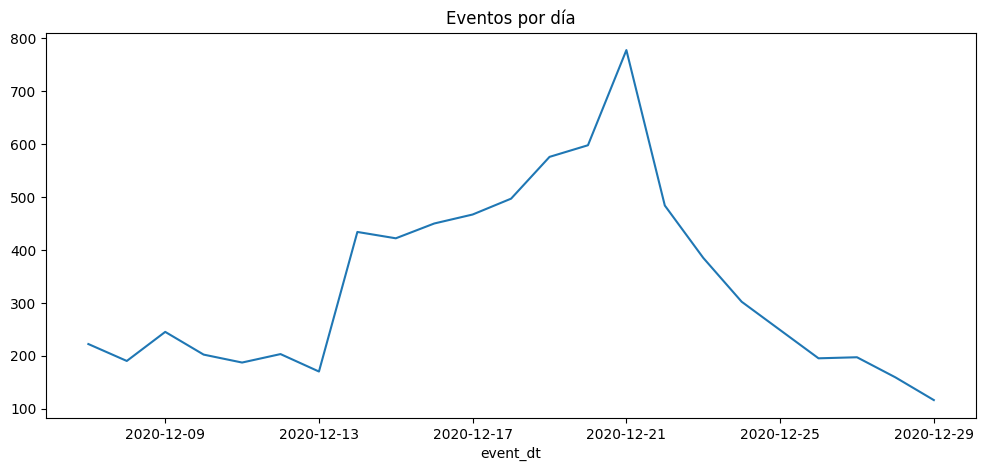

In [94]:
# Grafica de eventos por dia
daily.plot(figsize=(12,5))
plt.title("Eventos por día")
plt.show()

Aquí normalmente se observa una fuerte caída después del 21 de diciembre, ya que dejaron de incorporarse nuevos usuarios.

In [95]:
# Embudo
funnel = (df.groupby('event_name')['user_id'].nunique().reindex(['login', 'product_page', 'product_cart', 'purchase']))

In [96]:
funnel.head()

event_name
login           2593
product_page    1632
product_cart     773
purchase         804
Name: user_id, dtype: int64

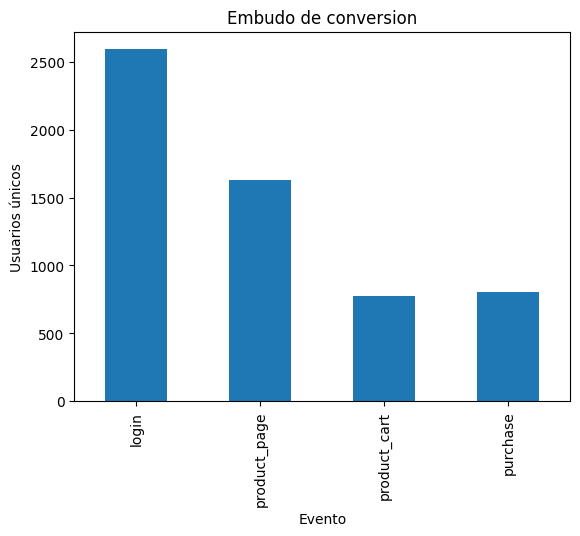

In [97]:
# Grafiaca de embudo
funnel.plot(kind='bar')
plt.title('Embudo de conversion')
plt.xlabel('Evento')
plt.ylabel('Usuarios únicos')
plt.show()

El embudo de conversión muestra la cantidad de usuarios únicos que alcanzaron cada una de las etapas del proceso de compra. Se observa una disminución importante en el número de usuarios desde login hasta product_page, y posteriormente hacia product_cart, lo que indica que una parte de los usuarios abandona el proceso antes de completar las siguientes etapas del embudo. Sin embargo, se observa que el número de usuarios que realizaron una purchase (804) es ligeramente superior al de aquellos que registraron un evento product_cart (773). Esto sugiere que algunos usuarios completaron una compra sin que se registrara previamente un evento de carrito, por lo que el flujo de eventos no sigue estrictamente la secuencia esperada del embudo. Esta particularidad debe considerarse al interpretar los resultados del experimento.

In [98]:
# Conversion por grupo
conversion = (df.pivot_table(index='group',columns='event_name',values='user_id',aggfunc='nunique'))

In [99]:
print(conversion)

event_name  login  product_cart  product_page  purchase
group                                                  
A            1939           589          1265       613
B             654           184           367       191


In [100]:
# Conversión
product = funnel['product_page']
cart = funnel['product_cart']
purchase = funnel['purchase']

print(cart/product)
print(purchase/cart)

0.4736519607843137
1.0401034928848643


## Parte 2. Analisis del Test A/B.

In [101]:
# Aplicar una prueba estadística (z-test) para cada prueba
exitos = np.array([
conversion.loc['A','product_page'],
conversion.loc['B','product_page']
])

intentos = np.array([
conversion.loc['A','login'],
conversion.loc['B','login']
])

stat, pvalue = proportions_ztest(exitos,intentos)
print(f'Estadístico z: {stat:.4f}, p-valor: {pvalue:.4f}')

Estadístico z: 4.1776, p-valor: 0.0000


La prueba z para comparar las proporciones de conversión entre login y product_page arrojó un estadístico de z = 4.1776 y un p-valor < 0.05. Dado que el p-valor es menor que el nivel de significancia de 0.05, se rechaza la hipótesis nula. 

Esto indica que existe una diferencia estadísticamente significativa entre las tasas de conversión de los grupos A y B en esta etapa del embudo. Sin embargo, esta diferencia debe interpretarse con cautela, ya que durante el análisis exploratorio se identificó un desequilibrio en el tamaño de las muestras, lo que podría influir en los resultados del experimento.

In [102]:
exitos = np.array([
conversion.loc['A','product_cart'],
conversion.loc['B','product_cart']
])

intentos = np.array([
conversion.loc['A','product_page'],
conversion.loc['B','product_page']
])

stat, pvalue = proportions_ztest(exitos,intentos)
print(f'Estadístico z: {stat:.4f}, p-valor: {pvalue:.4f}')

Estadístico z: -1.2076, p-valor: 0.2272


La prueba z para comparar las proporciones de conversión entre las etapas product_page y product_cart arrojó un estadístico de z = -1.2076 y un p-valor = 0.2272. Dado que el p-valor es mayor que el nivel de significancia de 0.05, no se rechaza la hipótesis nula. 

Esto indica que no existe evidencia estadísticamente significativa para afirmar que las tasas de conversión entre los grupos A y B sean diferentes en esta etapa del embudo. Por lo tanto, con los datos disponibles no es posible concluir que la variante evaluada haya modificado la probabilidad de que los usuarios pasen de visualizar un producto a agregarlo al carrito. Además, este resultado debe interpretarse considerando las limitaciones identificadas durante el análisis exploratorio, como el desequilibrio en el tamaño de las muestras.

In [103]:
exitos = np.array([
conversion.loc['A','purchase'],
conversion.loc['B','purchase']
])

intentos = np.array([
conversion.loc['A','login'],
conversion.loc['B','login']
])

stat, pvalue = proportions_ztest(exitos,intentos)
print(f'Estadístico z: {stat:.4f}, p-valor: {pvalue:.4f}')

Estadístico z: 1.1520, p-valor: 0.2493


La prueba z para comparar las proporciones de conversión entre login y purchase arrojó un estadístico de z = 1.1520 y un p-valor = 0.2493. Dado que el p-valor es mayor que el nivel de significancia de 0.05, no se rechaza la hipótesis nula.

Esto indica que no existe evidencia estadísticamente significativa para afirmar que las tasas de conversión desde el inicio de sesión hasta la compra final sean diferentes entre los grupos A y B. En consecuencia, con los datos analizados no es posible concluir que la variante evaluada haya mejorado la probabilidad de que los usuarios completen una compra. Además, este resultado debe interpretarse considerando las limitaciones identificadas durante el análisis exploratorio, especialmente el desequilibrio en el tamaño de las muestras.

<div class="alert alert-block alert-success">
<b>Comentario Revisor</b> <a class="tocSkip"></a>

Gran trabajo complementando con el calculo de la z-score y con el desarrollo de la prueba de hipótesis.

# Conclusion final

Durante este proyecto se realizó un análisis de la prueba A/B recommender_system_test con el objetivo de evaluar si el nuevo sistema de recomendaciones mejoraba la conversión de los usuarios dentro del embudo de compra.

En la etapa inicial de exploración de datos se verificó la calidad de los datasets, realizando ajustes en los tipos de datos, revisión de valores ausentes y eliminación de registros duplicados. Después de la limpieza, se analizaron las características principales de los participantes y se identificaron algunas limitaciones en la implementación de la prueba, principalmente un desequilibrio importante entre los grupos: el grupo A contó con 2,747 usuarios, mientras que el grupo B tuvo únicamente 928 usuarios. Esta diferencia debe considerarse al interpretar los resultados, ya que una distribución desigual puede afectar la precisión de las comparaciones estadísticas.

En el análisis exploratorio del comportamiento de los usuarios se observó que la mayoría de los participantes realizó un número reducido de eventos, mientras que solo una pequeña proporción tuvo una actividad más elevada. Después de eliminar duplicados, ambos grupos mostraron patrones de interacción similares, aunque el grupo A presentó una mayor cantidad de eventos debido a su mayor número de participantes.

El análisis del embudo de conversión permitió observar la disminución progresiva de usuarios a medida que avanzaban en el proceso de compra, desde la visualización de productos hasta la compra final. Este comportamiento es esperado en una tienda en línea, ya que no todos los usuarios que interactúan con la plataforma completan una compra.